# Calibrated Decisions Lab
**The core idea behind TypeSafe AI's Jev (Sept 2026): a model whose confidence numbers tell the truth.**

We simulate the *principle* — not TypeSafe's proprietary model or its RLCD training. Two forecasters predict whether each of 20,000 shell commands is unsafe:
- **Chatty** — an overconfident forecaster, like verbalized LLM confidence pushed to extremes.
- **Calibrated** — a Jev-style decision head whose stated probabilities match reality.

We then measure calibration the way the field does (reliability diagrams, ECE, proper scoring rules) and show why it becomes money the moment you automate on thresholds.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(7)
n = 20000
X = rng.normal(size=(n, 3))                      # command features
logit = 1.2*X[:,0] - 0.8*X[:,1] + 0.5*X[:,2]
p_true = 1/(1+np.exp(-logit))                     # true P(unsafe)
y = (rng.random(n) < p_true).astype(int)          # observed outcomes

# Chatty: overconfident — sharpens true odds toward 0/1 (like LLM verbalized confidence)
l = np.log(np.clip(p_true,1e-6,1-1e-6)/(1-np.clip(p_true,1e-6,1-1e-6)))
p_chat = np.clip(1/(1+np.exp(-3.0*l)), 0.01, 0.99)
# Calibrated: honest noise around the truth (what RLCD-style training aims for)
p_cal = np.clip(p_true + rng.normal(0, 0.02, n), 0.01, 0.99)
print(f"base rate of unsafe commands: {y.mean():.3f}")

base rate of unsafe commands: 0.499


## 1. Measuring honesty: ECE and proper scoring rules
**Expected Calibration Error (ECE)** bins predictions by confidence and averages |accuracy − confidence|. **Brier score** and **log-loss** are *proper scoring rules*: they are minimized only by reporting your true belief, so they punish confident wrongness. This is the family of objectives RLCD-style training optimizes.

In [ ]:
def ece(p, y, bins=10):
    edges = np.linspace(0,1,bins+1); idx = np.clip(np.digitize(p,edges)-1,0,bins-1); e=0.0
    for b in range(bins):
        m = idx==b
        if m.sum()>0: e += m.mean()*abs(y[m].mean()-p[m].mean())
    return e

def brier(p,y): return float(np.mean((p-y)**2))

def logloss(p,y):
    pc = np.clip(p,1e-12,1-1e-12)
    return float(-np.mean(y*np.log(pc)+(1-y)*np.log(1-pc)))

print(f"{'model':<28}{'ECE':>8}{'Brier':>9}{'log-loss':>10}")
for name,p in [("overconfident LLM-style",p_chat),("calibrated Jev-style",p_cal)]:
    print(f"{name:<28}{ece(p,y):>8.4f}{brier(p,y):>9.4f}{logloss(p,y):>10.4f}")

model                            ECE    Brier  log-loss
overconfident LLM-style       0.1444   0.1994    0.6880
calibrated Jev-style          0.0092   0.1749    0.5238


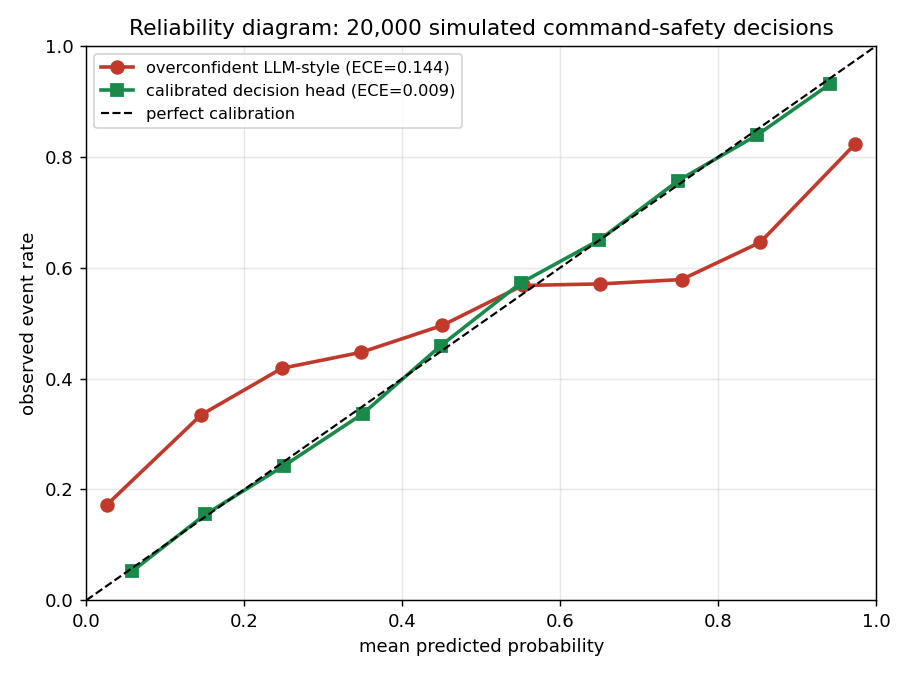

In [ ]:
# reliability diagram
def rel_curve(p, y, bins=10):
    edges=np.linspace(0,1,bins+1); idx=np.clip(np.digitize(p,edges)-1,0,bins-1)
    cx,cy=[],[]
    for b in range(bins):
        m=idx==b
        if m.sum()>0: cx.append(p[m].mean()); cy.append(y[m].mean())
    return np.array(cx),np.array(cy)

fig,ax=plt.subplots(figsize=(7,5.2))
cx,cy=rel_curve(p_chat,y); ax.plot(cx,cy,"o-",color="#c0392b",lw=2,ms=7,label=f"overconfident LLM-style (ECE={ece(p_chat,y):.3f})")
cx,cy=rel_curve(p_cal,y);  ax.plot(cx,cy,"s-",color="#1a8a4a",lw=2,ms=7,label=f"calibrated decision head (ECE={ece(p_cal,y):.3f})")
ax.plot([0,1],[0,1],"k--",lw=1.2,label="perfect calibration")
ax.set(xlim=(0,1),ylim=(0,1),xlabel="mean predicted probability",ylabel="observed event rate")
ax.set_title("Reliability diagram: 20,000 simulated command-safety decisions")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.show()

The overconfident curve sags *below* the diagonal: when it says 90%, the event happens ~70% of the time. The calibrated curve rides the diagonal — 70% means 70%.

## 2. Thresholds: where calibration becomes money
Automating means thresholding: flag the command if P(unsafe) ≥ t. Suppose a false alarm costs $1 (friction) and a missed unsafe command costs $10 (incident). Decision theory gives the optimal threshold in closed form:

**t* = C_FP / (C_FP + C_FN) = 1/11 ≈ 0.091**

But that formula *assumes calibrated probabilities*. Watch what happens when the numbers lie:

In [ ]:
C_FP, C_FN = 1.0, 10.0
t_star = C_FP/(C_FP+C_FN)
ts = np.linspace(0.01,0.6,150)

def cost_at(p,t):
    flag=p>=t; fp=np.sum(flag&(y==0)); fn=np.sum(~flag&(y==1))
    return (fp*C_FP+fn*C_FN)/n*1000          # $ per 1,000 commands

cc_chat=np.array([cost_at(p_chat,t) for t in ts])
cc_cal =np.array([cost_at(p_cal,t)  for t in ts])
print(f"cost at theoretical t*={t_star:.4f}:")
print(f"  overconfident : ${cost_at(p_chat,t_star):7.2f} / 1k commands")
print(f"  calibrated    : ${cost_at(p_cal,t_star):7.2f} / 1k commands")
print("empirical best threshold:")
print(f"  overconfident : t={ts[np.argmin(cc_chat)]:.3f} -> ${cc_chat.min():.2f} / 1k")
print(f"  calibrated    : t={ts[np.argmin(cc_cal)]:.3f} -> ${cc_cal.min():.2f} / 1k  (lands on theory)")

cost at theoretical t*=0.0909:
  overconfident : $ 768.90 / 1k commands
  calibrated    : $ 469.90 / 1k commands
empirical best threshold:
  overconfident : t=0.010 -> $500.90 / 1k
  calibrated    : t=0.105 -> $468.00 / 1k  (lands on theory)


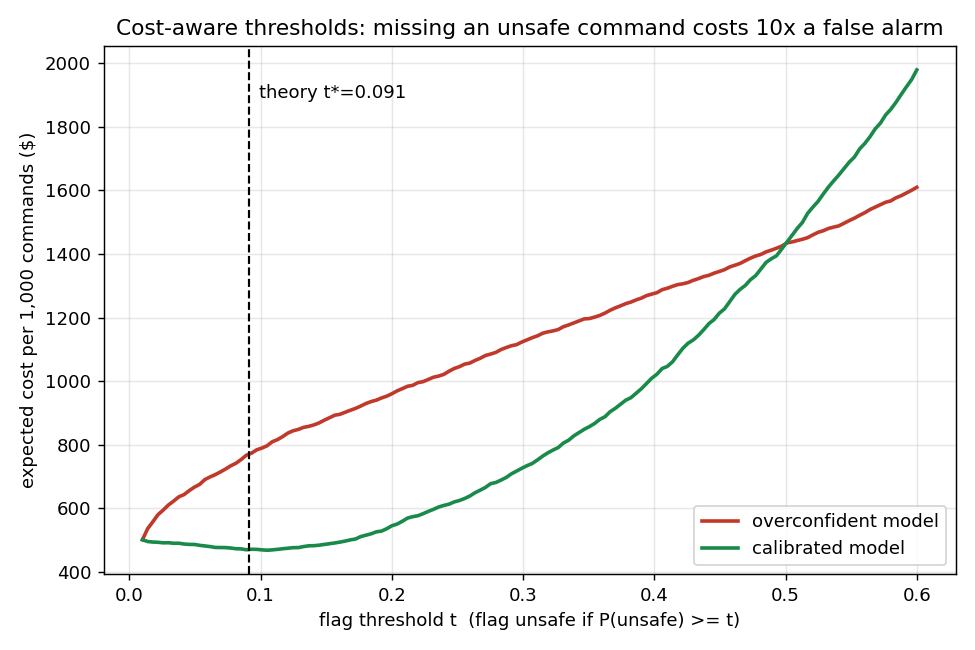

In [ ]:
fig,ax=plt.subplots(figsize=(7.5,5))
ax.plot(ts,cc_chat,color="#c0392b",lw=2,label="overconfident model")
ax.plot(ts,cc_cal,color="#1a8a4a",lw=2,label="calibrated model")
ax.axvline(t_star,color="k",ls="--",lw=1.2)
ax.text(t_star+0.008,ax.get_ylim()[1]*0.92,f"theory t*={t_star:.3f}",fontsize=10)
ax.set(xlabel="flag threshold t  (flag unsafe if P(unsafe) >= t)",ylabel="expected cost per 1,000 commands ($)")
ax.set_title("Cost-aware thresholds: missing an unsafe command costs 10x a false alarm")
ax.legend(); ax.grid(alpha=0.3); plt.show()

The calibrated model's empirical optimum lands exactly on the theoretical threshold — you can *compute* your operating point from your cost matrix. The overconfident model needs a different, unprincipled threshold, and even there it costs more. This is why Bryo AI's CTO called a real probability "ideal for automating workflows": thresholds transfer.

## 3. A toy decision head
Jev's output layer is a *decision head*, not a language-model head. The closest everyday analog: logistic regression, which outputs probabilities directly instead of generating text. Train one on the command features and check its calibration:

In [ ]:
clf = LogisticRegression(max_iter=300).fit(X, y)   # the 'System One' head
p_lr = clf.predict_proba(X)[:,1]
print(f"logistic decision head: ECE={ece(p_lr,y):.4f}  Brier={brier(p_lr,y):.4f}  log-loss={logloss(p_lr,y):.4f}")

logistic decision head: ECE=0.0093  Brier=0.1744  log-loss=0.5222


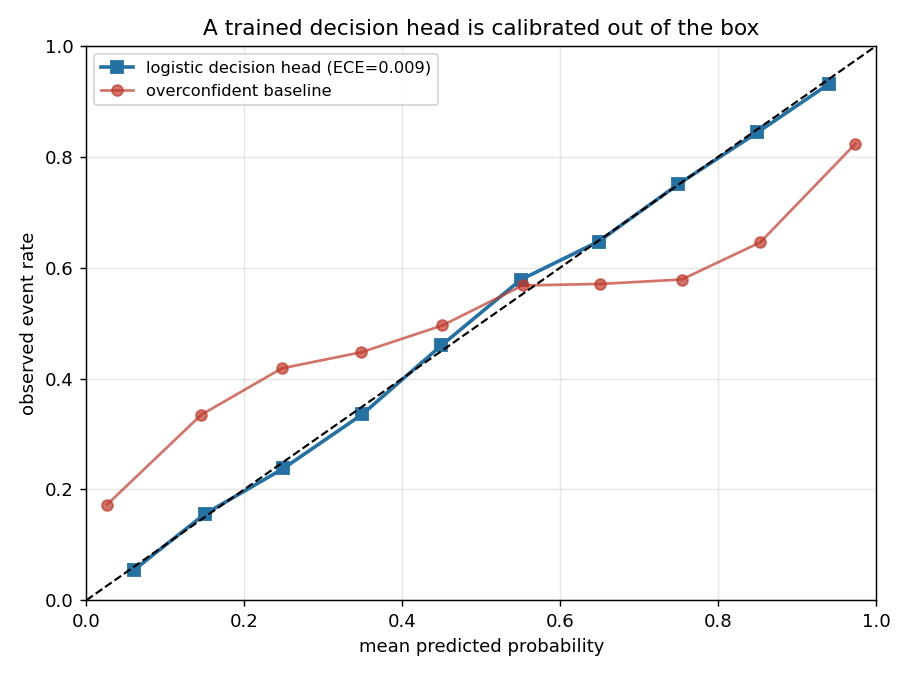

In [ ]:
fig,ax=plt.subplots(figsize=(7,5.2))
cx,cy=rel_curve(p_lr,y);   ax.plot(cx,cy,"s-",color="#2471a3",lw=2,ms=7,label=f"logistic decision head (ECE={ece(p_lr,y):.3f})")
cx,cy=rel_curve(p_chat,y); ax.plot(cx,cy,"o-",color="#c0392b",lw=1.5,ms=6,alpha=0.7,label="overconfident baseline")
ax.plot([0,1],[0,1],"k--",lw=1.2)
ax.set(xlim=(0,1),ylim=(0,1),xlabel="mean predicted probability",ylabel="observed event rate")
ax.set_title("A trained decision head is calibrated out of the box")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.show()

## Takeaways
1. **Calibration is measurable**: reliability diagrams, ECE, Brier score, log-loss.
2. **Proper scoring rules punish confident wrongness** — optimizing them (RLCD's idea) manufactures honesty.
3. **Thresholds only transfer when probabilities are honest**: t* = C_FP/(C_FP + C_FN).
4. A decision head that outputs probabilities directly starts life calibrated; a chat model that verbalizes confidence does not.

*Companion to the Medium post "The Model That Doesn't Talk" (2026-09-24). All data here is synthetic and illustrative — it demonstrates the calibration principle, not TypeSafe AI's proprietary Jev model or RLCD training.*